In [1]:
import pygris
from pygris import blocks, tracts
from pygris.utils import erase_water
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import folium
import shapely


In [2]:
job_data = pd.read_csv('../data/ny_wac_S000_JT00_2023.csv.gz')
job_data["w_geocode_tracts"] = job_data["w_geocode"].astype(str).str[:-4]
job_data = job_data[["w_geocode_tracts", "w_geocode", "C000"]]

job_data['w_geocode'] = job_data['w_geocode'].astype(str)

print(job_data.head())

  w_geocode_tracts        w_geocode  C000
0      36001000100  360010001001003     7
1      36001000100  360010001001004    52
2      36001000100  360010001001005    77
3      36001000100  360010001001006    43
4      36001000100  360010001001007   149


In [3]:
STATE = "36"  # New York State

COUNTIES = [
    # "005",  # Bronx
    # "047",  # Brooklyn (Kings County)
    # "061",  # Manhattan
    # "081",  # Queens
    "085"   # Staten Island (Richmond County)
]

YEAR = 2024

In [4]:
gdf_blocks = pygris.blocks(state = STATE, county = COUNTIES, year = YEAR)
gdf_blocks = erase_water(gdf_blocks)

gdf_blocks['GEOID20'] = gdf_blocks['GEOID20'].astype(str)

# Calculate centroids
gdf_blocks = gdf_blocks.to_crs(epsg=3857)
gdf_blocks['centroid'] = gdf_blocks.geometry.centroid

print(gdf_blocks.head(2))

  STATEFP20 COUNTYFP20 TRACTCE20 BLOCKCE20          GEOID20  \
0        36        085    017600      3018  360850176003018   
1        36        085    029102      1042  360850291021042   

                  GEOIDFQ20     NAME20 MTFCC20 UR20 UACE20 FUNCSTAT20  \
0  1000000US360850176003018  Block3018   G5040    U  63217          S   
1  1000000US360850291021042  Block1042   G5040    U  63217          S   

   ALAND20  AWATER20   INTPTLAT20    INTPTLON20  HOUSING20  POP20  \
0   164735     45133  +40.5242975  -074.1773117         34     79   
1   437216     28446  +40.6061302  -074.1882341          0      0   

                                            geometry  \
0  POLYGON ((-8257502.718 4942780.16, -8257483.01...   
1  POLYGON ((-8258906.568 4954702.39, -8258849.79...   

                           centroid  
0  POINT (-8257380.565 4942426.861)  
1  POINT (-8258472.888 4954541.487)  


In [5]:
merged_gdf_blocks = gdf_blocks.copy().merge(job_data, left_on='GEOID20', right_on='w_geocode', how='left')

In [6]:
print(merged_gdf_blocks.head(2))

  STATEFP20 COUNTYFP20 TRACTCE20 BLOCKCE20          GEOID20  \
0        36        085    017600      3018  360850176003018   
1        36        085    029102      1042  360850291021042   

                  GEOIDFQ20     NAME20 MTFCC20 UR20 UACE20  ... AWATER20  \
0  1000000US360850176003018  Block3018   G5040    U  63217  ...    45133   
1  1000000US360850291021042  Block1042   G5040    U  63217  ...    28446   

    INTPTLAT20    INTPTLON20 HOUSING20 POP20  \
0  +40.5242975  -074.1773117        34    79   
1  +40.6061302  -074.1882341         0     0   

                                            geometry  \
0  POLYGON ((-8257502.718 4942780.16, -8257483.01...   
1  POLYGON ((-8258906.568 4954702.39, -8258849.79...   

                           centroid w_geocode_tracts        w_geocode   C000  
0  POINT (-8257380.565 4942426.861)      36085017600  360850176003018  102.0  
1  POINT (-8258472.888 4954541.487)      36085029102  360850291021042  518.0  

[2 rows x 22 columns]


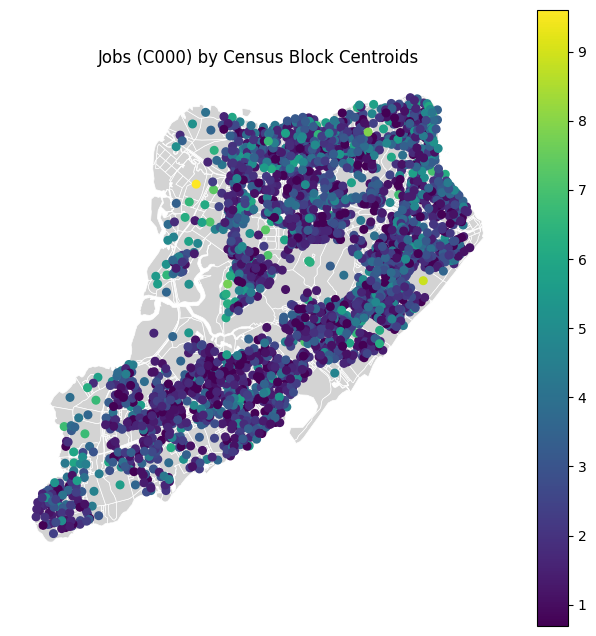

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

merged_gdf_blocks.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="white",
    linewidth=0.5
)

merged_gdf_blocks.set_geometry("centroid").plot(
    ax=ax,
    column=np.log1p(merged_gdf_blocks["C000"]),
    cmap="viridis",
    markersize=30,
    legend=True
)

ax.set_title("Jobs (C000) by Census Block Centroids")
ax.set_axis_off()

plt.show()

In [8]:
gdf_tracts = pygris.tracts(state = STATE, county = COUNTIES, year = 2024)
gdf_tracts = erase_water(gdf_tracts)

gdf_tracts['GEOID'] = gdf_tracts['GEOID'].astype(str)

# Calculate centroids
gdf_tracts = gdf_tracts.to_crs(epsg=3857)
gdf_tracts['centroid'] = gdf_tracts.geometry.centroid

print(gdf_tracts.head())

  STATEFP COUNTYFP TRACTCE        GEOID               GEOIDFQ    NAME  \
0      36      085  014605  36085014605  1400000US36085014605  146.05   
1      36      085  014606  36085014606  1400000US36085014606  146.06   
2      36      085  015100  36085015100  1400000US36085015100     151   
3      36      085  015601  36085015601  1400000US36085015601  156.01   
4      36      085  015602  36085015602  1400000US36085015602  156.02   

              NAMELSAD  MTFCC FUNCSTAT    ALAND  AWATER     INTPTLAT  \
0  Census Tract 146.05  G5020        S   875799    6861  +40.5588899   
1  Census Tract 146.06  G5020        S  1768732     192  +40.5612628   
2     Census Tract 151  G5020        S  1004814       0  +40.6195298   
3  Census Tract 156.01  G5020        S  1429954       0  +40.5421524   
4  Census Tract 156.02  G5020        S   881072       0  +40.5360199   

       INTPTLON                                           geometry  \
0  -074.1495429  POLYGON ((-8254991.573 4948209.801, -8254

In [9]:
import r5py

transport_network = r5py.TransportNetwork("../data/new-york-260512.osm.pbf",  "../data/gtfs_subway.zip")

In [10]:
origins = gdf_tracts.copy()
origins.geometry = origins.geometry.centroid

destinations = gdf_blocks.copy()
destinations.geometry = destinations.geometry.centroid

In [11]:
origins["id"] = origins["GEOID"]
destinations["id"] = destinations["GEOID20"]

In [12]:
import datetime

In [13]:
import datetime

travel_time_matrix = r5py.TravelTimeMatrix(
    transport_network,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.WALK],
    departure=datetime.datetime(2026, 5, 17, 14, 0, 0),
)

In [14]:
print(travel_time_matrix.head())

       from_id            to_id  travel_time
0  36085014605  360850176003018         95.0
1  36085014605  360850291021042          NaN
2  36085014605  360850323001010          NaN
3  36085014605  360850128054005         90.0
4  36085014605  360850291021010          NaN


In [15]:
travel_time_matrix.pivot(index="from_id", columns="to_id", values="travel_time")

to_id,360850003001000,360850003001001,360850003001002,360850003001003,360850003001004,360850003002000,360850003002001,360850003002002,360850003002003,360850003002004,...,360850323001016,360850323001017,360850323001018,360850323001019,360850323001020,360850323001021,360850323001022,360850323001023,360850323001024,360850323001025
from_id,,,,,,,,,,,,,,,,,,,,,
36085000300,6.0,4.0,6.0,3.0,9.0,9.0,2.0,1.0,2.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36085000600,63.0,61.0,63.0,61.0,65.0,56.0,55.0,58.0,57.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36085000700,17.0,14.0,13.0,13.0,10.0,23.0,17.0,15.0,16.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36085000800,67.0,65.0,67.0,65.0,69.0,61.0,59.0,62.0,61.0,59.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36085000900,19.0,16.0,17.0,15.0,15.0,24.0,18.0,16.0,17.0,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36085030301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,37.0,33.0,38.0,39.0,54.0,41.0,44.0,37.0,37.0,29.0
36085030302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,25.0,22.0,26.0,39.0,54.0,31.0,32.0,32.0,35.0,32.0
36085031901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.0,13.0,14.0,29.0,44.0,21.0,23.0,22.0,25.0,30.0


In [43]:
THRESHOLD = 15

In [44]:
reachable = travel_time_matrix[travel_time_matrix["travel_time"] <= THRESHOLD]

In [45]:
print(reachable.head())

         from_id            to_id  travel_time
24   36085014605  360850146051005          9.0
141  36085014605  360850146082007         14.0
147  36085014605  360850146051014          6.0
163  36085014605  360850146061004         11.0
240  36085014605  360850146081009         13.0


In [46]:
reachable = reachable.merge(
    merged_gdf_blocks[['GEOID20', 'C000']],
    left_on='to_id',
    right_on='GEOID20',
    how='left'
).drop(columns=['GEOID20'])

In [47]:
print(reachable)

          from_id            to_id  travel_time  C000
0     36085014605  360850146051005          9.0   1.0
1     36085014605  360850146082007         14.0   NaN
2     36085014605  360850146051014          6.0   NaN
3     36085014605  360850146061004         11.0   NaN
4     36085014605  360850146081009         13.0   NaN
...           ...              ...          ...   ...
5900  36085024401  360850244013014         12.0   NaN
5901  36085024401  360850244013008         15.0   2.0
5902  36085024401  360850244013005         11.0  10.0
5903  36085024401  360850244021003         14.0   NaN
5904  36085024401  360850248002012         14.0   NaN

[5905 rows x 4 columns]


In [48]:
access = (
    reachable.groupby('from_id', as_index=False)['C000']
      .sum()
      .rename(columns={'C000': 'accessible_jobs'})
)

In [49]:
print(access)

         from_id  accessible_jobs
0    36085000300           4918.0
1    36085000600            916.0
2    36085000700           3876.0
3    36085000800           1075.0
4    36085000900           3454.0
..           ...              ...
120  36085030301            747.0
121  36085030302            898.0
122  36085031901           1110.0
123  36085031902            286.0
124  36085032300             34.0

[125 rows x 2 columns]


In [50]:
gdf = gdf_tracts.merge(
    access,
    left_on='GEOID',   # or correct tract id column
    right_on='from_id',
    how='left'
)

In [51]:
gdf['accessible_jobs'] = gdf['accessible_jobs'].fillna(0)

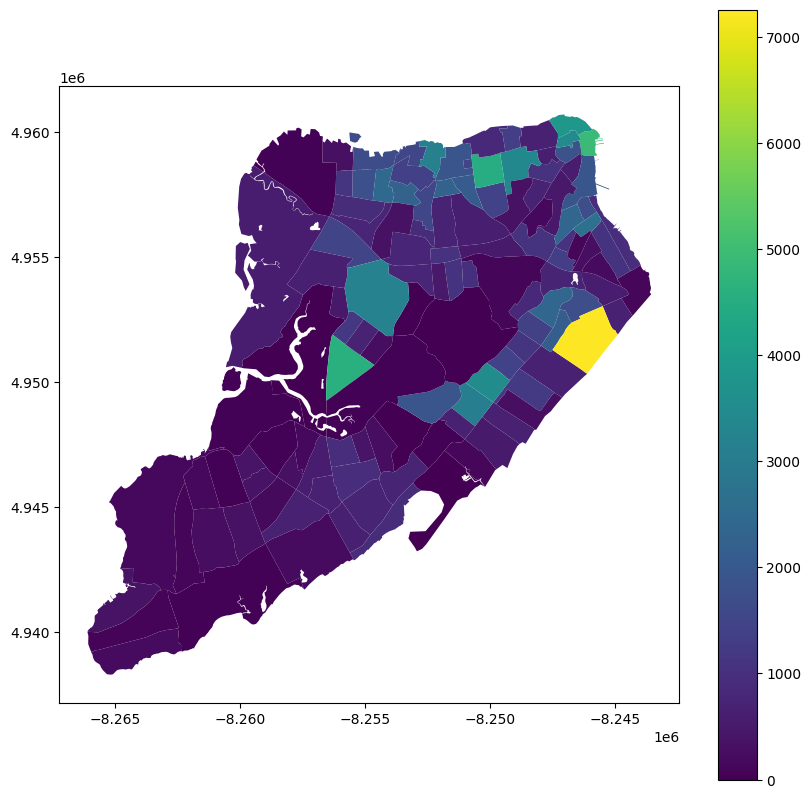

In [52]:
ax = gdf.plot(
    column='accessible_jobs',
    legend=True,
    figsize=(10, 10)
)